# CS-GY 9223 / CS-UY 3943 Neuroinformatics
# Microscopy, Calcium Imaging & Project 3 Preview

**Topics covered today:**
1. **Part 1 -- Microscopy & Calcium Imaging Code Lab**
   - Fluorescence microscopy basics
   - Loading & visualizing calcium imaging data
   - Non-negative Matrix Factorization (NMF) for source extraction
   - Denoising via low-rank approximation

2. **Part 2 -- Project 3: MERFISH Cell Segmentation (using real competition data)**
   - Loading raw .dax MERFISH images
   - DAPI/polyT visualization
   - Cell segmentation with Cellpose
   - Spot-to-cell assignment
   - Evaluation with Adjusted Rand Index (ARI)

---
# Part 1: Microscopy & Calcium Imaging Code Lab
---

## 1.1 Setup & Installations

In [1]:
!pip install -q numpy matplotlib scipy scikit-learn tifffile

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from scipy.ndimage import gaussian_filter
from sklearn.decomposition import NMF
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Imports ready!")

Imports ready!


## 1.2 Recap: Why Microscopy?

Recall from lecture:
- **Whole-brain imaging** (EEG, fMRI) cannot resolve individual neurons
- **Microscopy** fills the gap: single-cell resolution + molecular specificity
- **Fluorescence microscopy** uses fluorophores (GFP, GCaMP) to visualize specific molecules
- **2-photon microscopy** enables deeper imaging (~400+ um) with less photobleaching

Today we'll work through the computational pipeline that goes from raw microscopy video to extracted neural traces.

## 1.3 Simulating Calcium Imaging Data

Since we can't run a real microscope in Colab, we'll simulate realistic calcium imaging data.

The generative model (from lecture):

$$Y = AC + B + E$$

- $Y \in \mathbb{R}^{d \times T}$ -- observed imaging data (pixels x time)
- $A \in \mathbb{R}^{d \times K}$ -- spatial footprints of K neurons
- $C \in \mathbb{R}^{K \times T}$ -- temporal traces (calcium dynamics)
- $B \in \mathbb{R}^{d \times T}$ -- background fluorescence
- $E \in \mathbb{R}^{d \times T}$ -- noise

In [3]:
def simulate_calcium_trace(T, n_spikes=8, tau_rise=2, tau_decay=15, dt=1.0):
    """Simulate a single neuron's calcium trace with exponential decay kernel."""
    spike_times = np.sort(np.random.choice(T, size=n_spikes, replace=False))
    spikes = np.zeros(T)
    spikes[spike_times] = np.random.uniform(0.5, 1.5, n_spikes)
    t_kernel = np.arange(0, 5 * tau_decay, dt)
    kernel = (1 - np.exp(-t_kernel / tau_rise)) * np.exp(-t_kernel / tau_decay)
    kernel /= kernel.max()
    trace = np.convolve(spikes, kernel)[:T]
    return trace, spike_times

def make_spatial_footprint(height, width, center_y, center_x, radius=8):
    """Create a 2D Gaussian spatial footprint for a neuron."""
    yy, xx = np.mgrid[0:height, 0:width]
    footprint = np.exp(-((yy - center_y)**2 + (xx - center_x)**2) / (2 * radius**2))
    return footprint.ravel()

height, width = 100, 100
d = height * width
T = 300
K = 5
centers = [(np.random.randint(20, 80), np.random.randint(20, 80)) for _ in range(K)]

A_true = np.zeros((d, K))
C_true = np.zeros((K, T))
for k in range(K):
    A_true[:, k] = make_spatial_footprint(height, width, centers[k][0], centers[k][1],
                                          radius=np.random.uniform(5, 12))
    C_true[k], _ = simulate_calcium_trace(T, n_spikes=np.random.randint(5, 15))

background = np.clip(0.3 * np.ones((d, 1)) + 0.1 * np.random.randn(d, 1), 0, None)
Y = np.clip(A_true @ C_true + background + 0.15 * np.random.randn(d, T), 0, None)

print(f"Simulated data: Y shape = {Y.shape} ({d} pixels x {T} frames)")
print(f"Number of neurons: {K}")
print(f"Neuron centers: {centers}")

Simulated data: Y shape = (10000, 300) (10000 pixels x 300 frames)
Number of neurons: 5
Neuron centers: [(58, 71), (48, 34), (62, 27), (40, 58), (77, 38)]


## 1.4 Visualizing the Simulated Data

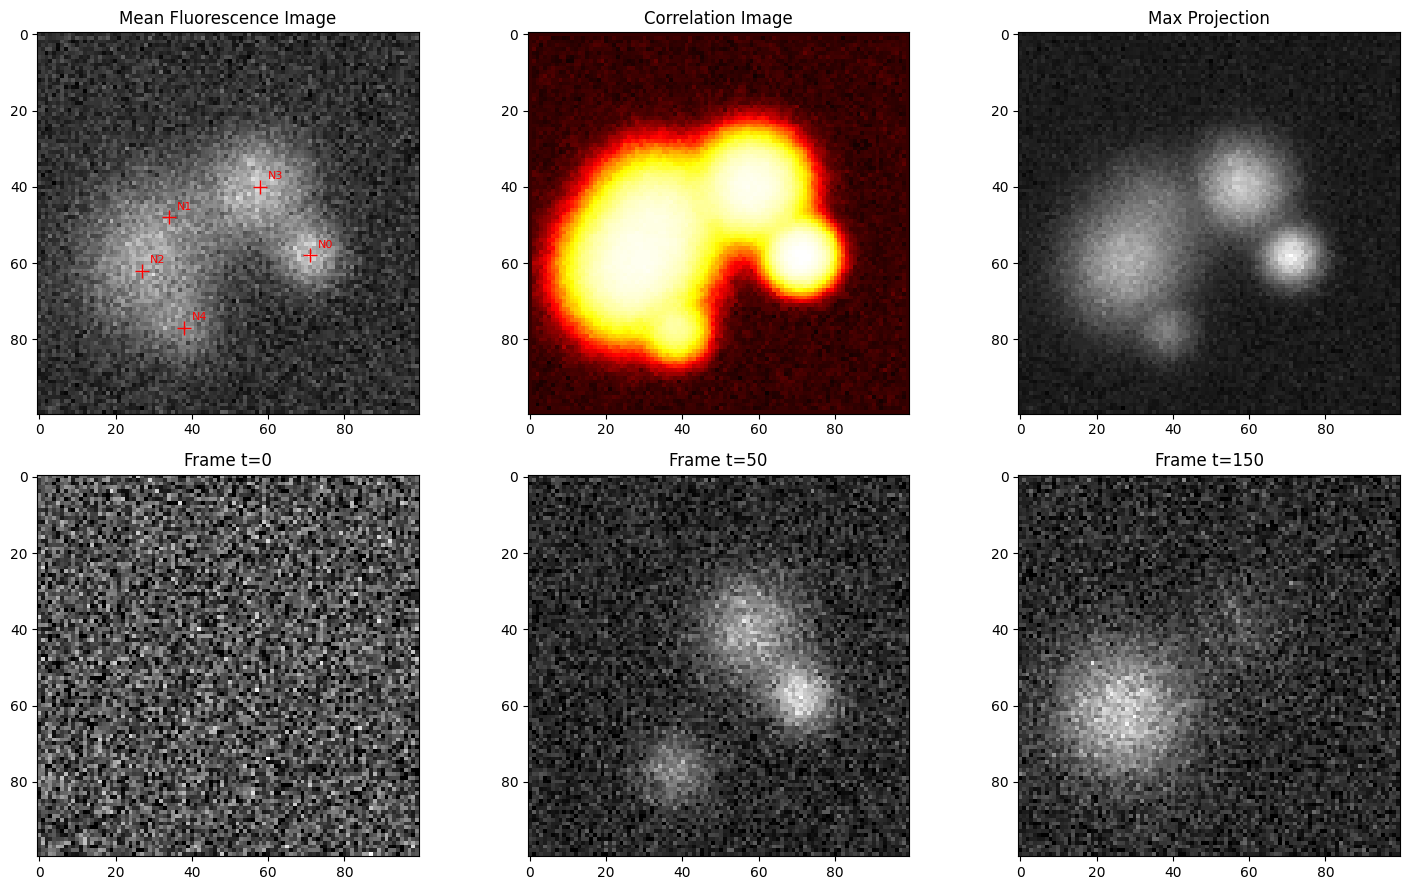

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

mean_img = Y.mean(axis=1).reshape(height, width)
axes[0, 0].imshow(mean_img, cmap='gray')
axes[0, 0].set_title('Mean Fluorescence Image')
for k, (cy, cx) in enumerate(centers):
    axes[0, 0].plot(cx, cy, 'r+', markersize=10)
    axes[0, 0].annotate(f'N{k}', (cx+2, cy-2), color='red', fontsize=8)

Y_reshaped = Y.reshape(height, width, T)
corr_img = np.zeros((height, width))
for i in range(1, height-1):
    for j in range(1, width-1):
        center_trace = Y_reshaped[i, j, :]
        neighbors = [Y_reshaped[i+di, j+dj, :] for di in [-1,0,1] for dj in [-1,0,1] if (di,dj) != (0,0)]
        corrs = [np.corrcoef(center_trace, n)[0,1] for n in neighbors]
        corr_img[i, j] = np.mean(corrs)
axes[0, 1].imshow(corr_img, cmap='hot')
axes[0, 1].set_title('Correlation Image')

max_img = Y.max(axis=1).reshape(height, width)
axes[0, 2].imshow(max_img, cmap='gray')
axes[0, 2].set_title('Max Projection')

for idx, t in enumerate([0, 50, 150]):
    axes[1, idx].imshow(Y[:, t].reshape(height, width), cmap='gray')
    axes[1, idx].set_title(f'Frame t={t}')

plt.tight_layout()
plt.show()

**Key observations:**
- The **mean image** shows where neurons are (brighter = more active overall)
- The **correlation image** highlights neurons clearly -- neighboring pixels in a neuron are highly correlated over time
- Individual frames are **very noisy** -- we need temporal information to denoise

## 1.5 Non-negative Matrix Factorization (NMF)

From the lecture, the core optimization problem:

$$\hat{A}, \hat{C} = \arg\min_{A, C} \|Y - AC\|_F^2 \quad \text{subject to} \quad A \geq 0, C \geq 0$$

NMF is ideal because:
- Fluorescence is **non-negative** (photon counts)
- Spatial footprints are **non-negative** (light intensity)
- Temporal traces are **non-negative** (calcium concentration)

In [5]:
model = NMF(n_components=K, init='nndsvda', max_iter=500, random_state=42)
A_hat = model.fit_transform(Y)
C_hat = model.components_
print(f"Estimated spatial footprints A_hat: {A_hat.shape}")
print(f"Estimated temporal traces C_hat: {C_hat.shape}")
print(f"Reconstruction error: {model.reconstruction_err_:.2f}")

Estimated spatial footprints A_hat: (10000, 5)
Estimated temporal traces C_hat: (5, 300)
Reconstruction error: 259.26


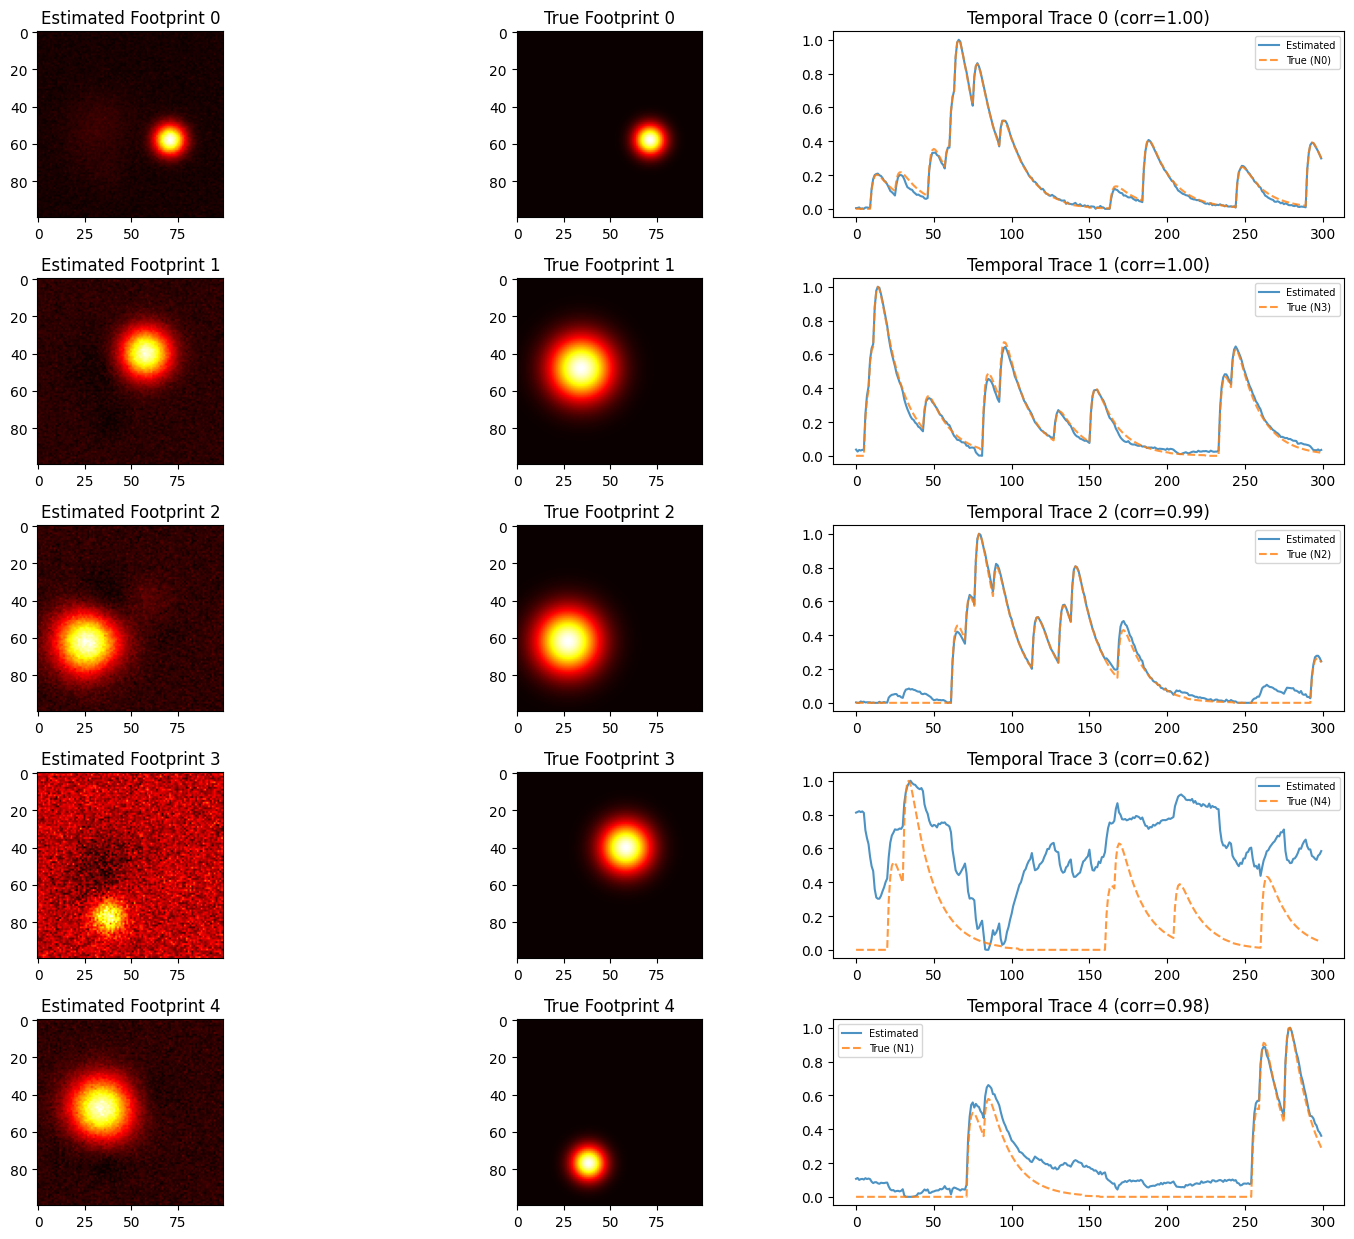

In [6]:
fig, axes = plt.subplots(K, 3, figsize=(15, 2.5*K))
for k in range(K):
    fp = A_hat[:, k].reshape(height, width)
    axes[k, 0].imshow(fp, cmap='hot')
    axes[k, 0].set_title(f'Estimated Footprint {k}')
    fp_true = A_true[:, k].reshape(height, width)
    axes[k, 1].imshow(fp_true, cmap='hot')
    axes[k, 1].set_title(f'True Footprint {k}')
    axes[k, 2].plot(C_hat[k] / C_hat[k].max(), label='Estimated', alpha=0.8)
    corrs = [np.corrcoef(C_hat[k], C_true[j])[0,1] for j in range(K)]
    best_match = np.argmax(corrs)
    axes[k, 2].plot(C_true[best_match] / C_true[best_match].max(), '--', label=f'True (N{best_match})', alpha=0.8)
    axes[k, 2].set_title(f'Temporal Trace {k} (corr={corrs[best_match]:.2f})')
    axes[k, 2].legend(fontsize=7)
plt.tight_layout()
plt.show()

## 1.6 Denoising via Low-Rank Approximation

The reconstruction $\hat{Y} = AC$ is a **denoised** version of the data.

From the lecture (Blockwise PCA / PMD approach):
- Locally, the signal is **very low rank** (few neurons per patch)
- Signal variance dominates noise variance
- SVD/NMF can separate signal from noise

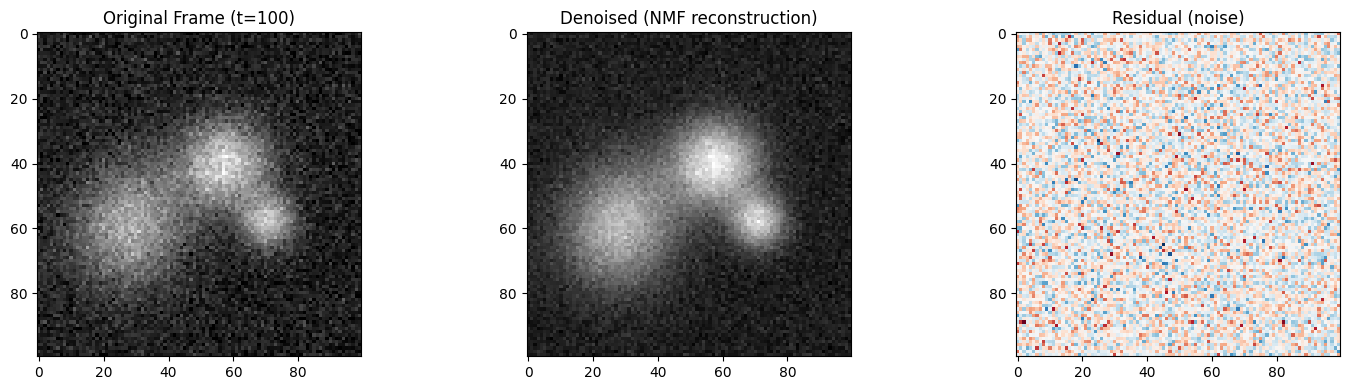

In [7]:
reconstruction = A_hat @ C_hat
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
frame_idx = 100
axes[0].imshow(Y[:, frame_idx].reshape(height, width), cmap='gray')
axes[0].set_title(f'Original Frame (t={frame_idx})')
axes[1].imshow(reconstruction[:, frame_idx].reshape(height, width), cmap='gray')
axes[1].set_title(f'Denoised (NMF reconstruction)')
residual = Y[:, frame_idx] - reconstruction[:, frame_idx]
axes[2].imshow(residual.reshape(height, width), cmap='RdBu_r')
axes[2].set_title('Residual (noise)')
plt.tight_layout()
plt.show()

## 1.7 Choosing the Number of Components

In practice, we don't know K. Use the **reconstruction error** vs K to find an "elbow".

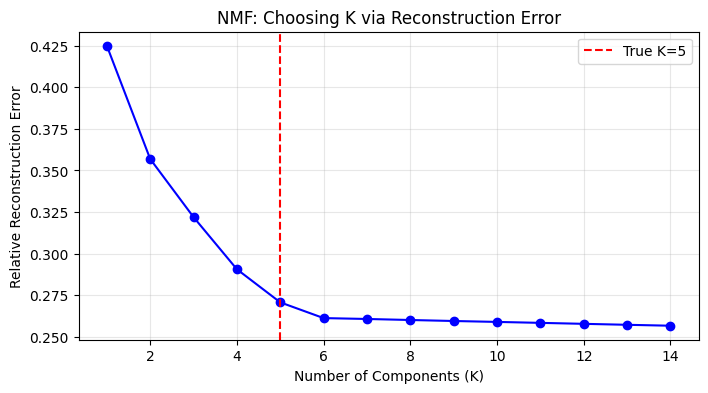

In [8]:
K_range = range(1, 15)
errors = []
for k in K_range:
    model_k = NMF(n_components=k, init='nndsvda', max_iter=300, random_state=42)
    A_k = model_k.fit_transform(Y)
    C_k = model_k.components_
    err = np.linalg.norm(Y - A_k @ C_k) / np.linalg.norm(Y)
    errors.append(err)

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), errors, 'bo-')
plt.axvline(x=K, color='r', linestyle='--', label=f'True K={K}')
plt.xlabel('Number of Components (K)')
plt.ylabel('Relative Reconstruction Error')
plt.title('NMF: Choosing K via Reconstruction Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 1.8 Delta F / F (dF/F)

$$\frac{\Delta F}{F_0} = \frac{F(t) - F_0}{F_0}$$

where $F_0$ is the baseline fluorescence (e.g., 10th percentile of the trace).

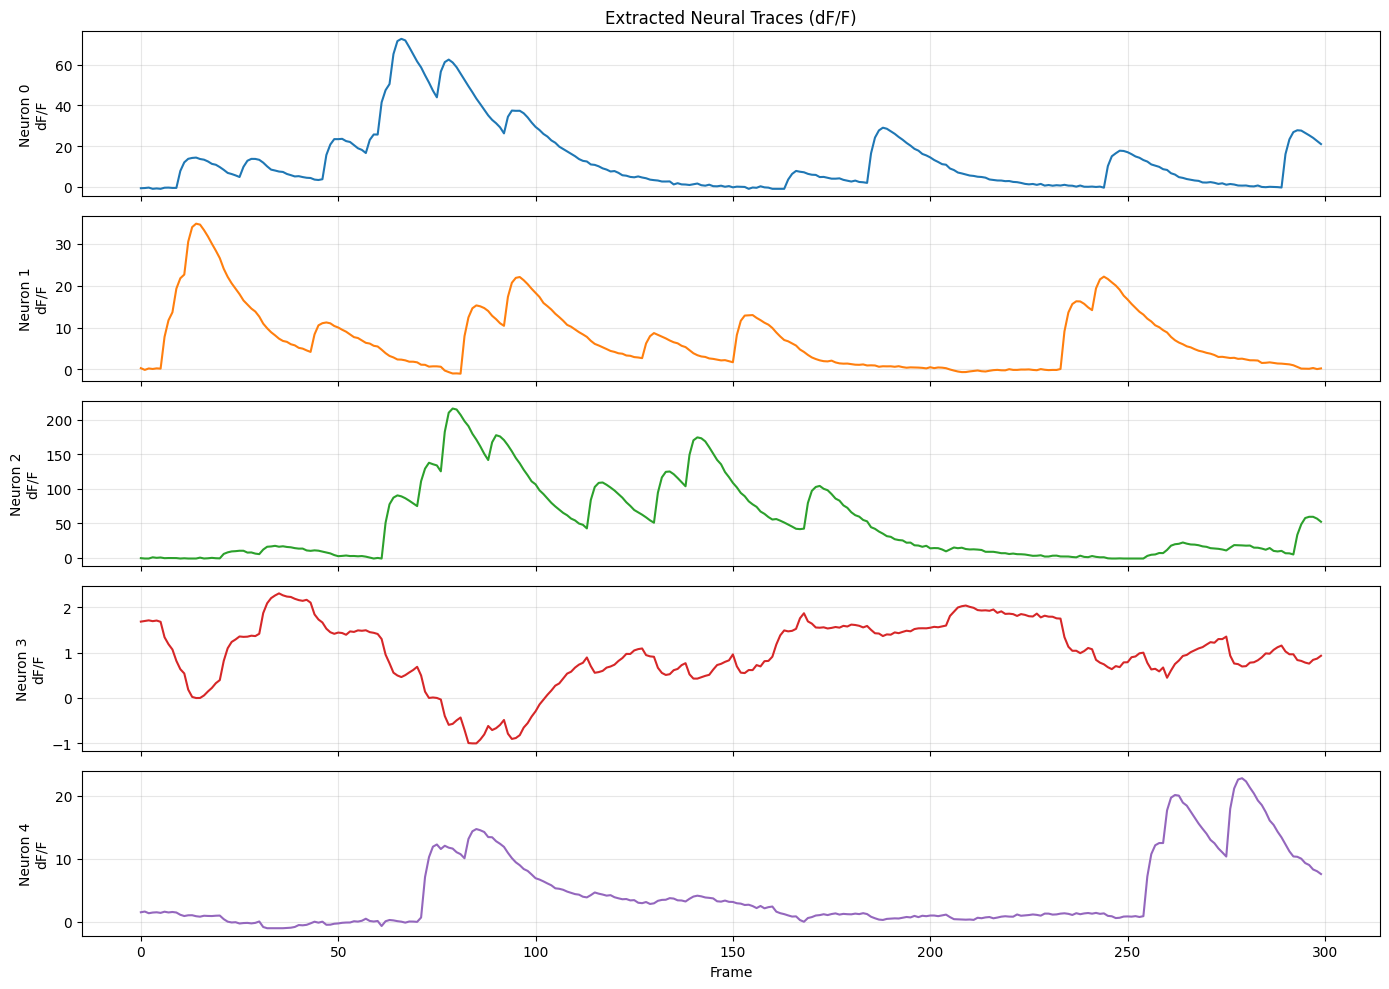

In [9]:
def compute_dff(trace, percentile=10):
    f0 = np.percentile(trace, percentile)
    if f0 <= 0:
        f0 = trace.mean()
    return (trace - f0) / f0

fig, axes = plt.subplots(K, 1, figsize=(14, 2*K), sharex=True)
for k in range(K):
    dff = compute_dff(C_hat[k])
    axes[k].plot(dff, color=f'C{k}')
    axes[k].set_ylabel(f'Neuron {k}\ndF/F')
    axes[k].grid(True, alpha=0.3)
axes[-1].set_xlabel('Frame')
axes[0].set_title('Extracted Neural Traces (dF/F)')
plt.tight_layout()
plt.show()

## 1.9 Summary: Calcium Imaging Pipeline

1. **Motion correction** -- align frames
2. **Denoising / dimensionality reduction** -- blockwise PCA (PMD)
3. **Source extraction** -- NMF/CNMF to get spatial footprints and temporal traces
4. **Spike deconvolution** -- infer spike times from calcium traces

Tools: [CaImAn](https://github.com/flatironinstitute/CaImAn), [Suite2p](https://github.com/MouseLand/suite2p)

---
# Part 2: Project 3 -- MERFISH Cell Segmentation
---

## 2.1 What is MERFISH?

**MERFISH** (Multiplexed Error-Robust Fluorescence In Situ Hybridization) is a spatial transcriptomics technique that images individual mRNA molecules *in situ* -- directly inside tissue sections.

Unlike bulk RNA-seq or single-cell RNA-seq, MERFISH preserves **spatial information**: you know *where* each transcript is in the tissue.

### How it works (simplified):
1. Tissue is labeled with fluorescent probes that bind specific mRNA sequences
2. Multiple rounds of imaging are performed (each round lights up different genes)
3. Each mRNA molecule appears as a bright **spot** in the image
4. A combinatorial barcode identifies which gene each spot belongs to
5. After decoding, you get a list of **(x, y, gene)** tuples -- the **decoded spots**

### The problem:
To get a gene expression matrix (genes x cells), you need to know which **cell** each spot belongs to. This requires **cell segmentation** of the tissue image.

### Your task in Project 3:
Given raw MERFISH images and decoded mRNA spot locations, **segment cells and assign each spot to a cell** (or to background).

## 2.2 The 18 Files Per FOV -- Explained

Each FOV folder contains 18 `.dax` files. Here's what each one is:

### The Epi file (1 file, 27 frames, ~227 MB)
`Epi-750s5-635s5-545s1-473s5-408s5_001.dax`

The filename lists the **laser wavelengths** used: 750nm, 635nm, 545nm, 473nm, 408nm.
Each laser excites a different fluorophore. The microscope cycles through all lasers at each z-plane:

| Laser | What it excites | What you see |
|-------|----------------|-------------|
| 408nm | DAPI (binds DNA) | **Nuclei** -- bright compact blobs |
| 473nm | polyT (binds mRNA tails) | **Cytoplasm** -- fuzzy cell bodies |
| 545nm | Gene fluorophore | Gene signal (for barcode round in Epi) |
| 635nm | Gene fluorophore | Gene signal (different color) |
| 750nm | Fiducial beads | Alignment reference (beads glued to slide) |

5 lasers × 5 z-planes = 25 frames (+2 extra = 27 total).

**Frame indices you care about:**

| | Z0 | Z1 | Z2 | Z3 | Z4 |
|---|---|---|---|---|---|
| polyT | 5 | 10 | **15** | 20 | 25 |
| DAPI | 6 | 11 | **16** | 21 | 26 |

### Gene round files (15 files, 17 frames each, ~143 MB each)
`Epi-750s5-635s5-545s1_001_00.dax` through `..._14.dax`

Notice: only 3 lasers (750, 635, 545) -- **no 473 or 408**. No DAPI or polyT here.
These are the 15 imaging rounds for barcode decoding. In each round, different genes light up.
The decoding is **already done for you** -- you get `spots_train.csv` with results.

### Fiducial files (2 files, ~42 MB each)
`Epi-750s1-635s1-545s1_001_0.dax` and `..._1.dax`

Only fiducial beads. Used for aligning rounds to each other. **You don't need these.**

### What students need to touch:
**Just the Epi file.** Load DAPI (frame 16) and polyT (frame 15) for segmentation. Ignore everything else.

## 2.3 Setup

We have real MERFISH data for FOV_001 available locally. Let's load and visualize it.

In [10]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '/scratch/vsp7230/Last_Colab/data'
DATA_DIR = './'
FOV_DIR = os.path.join(DATA_DIR, 'FOV_001')

print('Files in FOV_001:')
for f in sorted(os.listdir(FOV_DIR)):
    size_mb = os.path.getsize(os.path.join(FOV_DIR, f)) / 1e6
    print(f'  {f}  ({size_mb:.1f} MB)')

Files in FOV_001:


FileNotFoundError: [Errno 2] No such file or directory: './FOV_001'

## 2.4 Loading Raw .dax Images

`.dax` files are raw binary -- just a flat array of `uint16` pixels with no header.
Each frame is 2048 x 2048 pixels. We reshape based on the known dimensions.

In [ ]:
def load_dax(filepath, height=2048, width=2048):
    """Load a .dax raw image file. Raw uint16 binary, no header."""
    raw = np.fromfile(filepath, dtype=np.uint16)
    n_frames = len(raw) // (height * width)
    return raw.reshape(n_frames, height, width)

# Load the main Epi file
epi_path = os.path.join(FOV_DIR, 'Epi-750s5-635s5-545s1-473s5-408s5_001.dax')
epi_stack = load_dax(epi_path)
print(f'Epi stack shape: {epi_stack.shape}  (frames, height, width)')

# Extract DAPI and polyT from the middle z-plane (z2)
# DAPI frames: [6, 11, 16, 21, 26] for z0-z4
# polyT frames: [5, 10, 15, 20, 25] for z0-z4
z_plane = 2  # middle z-plane
dapi = epi_stack[6 + z_plane * 5]   # frame 16 for z2
polyt = epi_stack[5 + z_plane * 5]  # frame 15 for z2

print(f'DAPI shape: {dapi.shape}, dtype: {dapi.dtype}')
print(f'DAPI range: [{dapi.min()}, {dapi.max()}]')
print(f'polyT shape: {polyt.shape}, dtype: {polyt.dtype}')
print(f'polyT range: [{polyt.min()}, {polyt.max()}]')

## 2.5 Visualizing DAPI and polyT

DAPI stains nuclei (bright spots = cell nuclei). polyT labels cytoplasm via mRNA.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(dapi, cmap='gray', vmin=np.percentile(dapi, 1), vmax=np.percentile(dapi, 99.5))
axes[0].set_title('DAPI (nuclei)', fontsize=14)
axes[0].axis('off')

axes[1].imshow(polyt, cmap='gray', vmin=np.percentile(polyt, 1), vmax=np.percentile(polyt, 99.5))
axes[1].set_title('polyT (cytoplasm / mRNA)', fontsize=14)
axes[1].axis('off')

# Composite: DAPI=blue, polyT=green
composite = np.zeros((*dapi.shape, 3), dtype=np.float32)
dapi_norm = (dapi - np.percentile(dapi, 1)) / (np.percentile(dapi, 99.5) - np.percentile(dapi, 1))
polyt_norm = (polyt - np.percentile(polyt, 1)) / (np.percentile(polyt, 99.5) - np.percentile(polyt, 1))
composite[:, :, 2] = np.clip(dapi_norm, 0, 1)   # blue = DAPI
composite[:, :, 1] = np.clip(polyt_norm, 0, 1)   # green = polyT

axes[2].imshow(composite)
axes[2].set_title('Composite (blue=DAPI, green=polyT)', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Zoomed-in view to see individual cells
y_start, y_end = 800, 1200
x_start, x_end = 800, 1200

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(dapi[y_start:y_end, x_start:x_end], cmap='gray',
               vmin=np.percentile(dapi, 1), vmax=np.percentile(dapi, 99.5))
axes[0].set_title('DAPI (zoomed)', fontsize=14)
axes[0].axis('off')

crop_composite = composite[y_start:y_end, x_start:x_end]
axes[1].imshow(crop_composite)
axes[1].set_title('Composite (zoomed)', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 2.6 Cell Segmentation with Cellpose

[Cellpose](https://github.com/MouseLand/cellpose) is a deep learning model for cell segmentation.
It outputs a **mask image** where each cell gets a unique integer label (0 = background).

We use the pretrained `nuclei` model on our DAPI image.

In [ ]:
from cellpose.models import CellposeModel

# Cellpose v4+: use CellposeModel (not models.Cellpose)
model = CellposeModel(model_type='nuclei', gpu=True)

# eval() returns 3 values: masks, flows, styles
masks, flows, styles = model.eval(dapi, diameter=30, channels=[0, 0])

print(f'Segmentation complete!')
print(f'Mask shape: {masks.shape}')
print(f'Number of cells found: {masks.max()}')

## 2.7 Visualizing Segmentation Results

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(dapi, cmap='gray', vmin=np.percentile(dapi, 1), vmax=np.percentile(dapi, 99.5))
axes[0].set_title('DAPI (input)', fontsize=14)
axes[0].axis('off')

# Random colormap for masks
from matplotlib.colors import ListedColormap
np.random.seed(42)
colors = np.random.rand(masks.max() + 1, 4)
colors[:, 3] = 0.6  # alpha
colors[0] = [0, 0, 0, 0]  # background transparent
cmap = ListedColormap(colors)

axes[1].imshow(masks, cmap=cmap)
axes[1].set_title(f'Cellpose masks ({masks.max()} cells)', fontsize=14)
axes[1].axis('off')

# Overlay
axes[2].imshow(dapi, cmap='gray', vmin=np.percentile(dapi, 1), vmax=np.percentile(dapi, 99.5))
axes[2].imshow(masks, cmap=cmap, alpha=0.4)
axes[2].set_title('Overlay', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Zoomed view of segmentation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

crop_dapi = dapi[y_start:y_end, x_start:x_end]
crop_masks = masks[y_start:y_end, x_start:x_end]

axes[0].imshow(crop_dapi, cmap='gray', vmin=np.percentile(dapi, 1), vmax=np.percentile(dapi, 99.5))
axes[0].set_title('DAPI (zoomed)', fontsize=14)
axes[0].axis('off')

axes[1].imshow(crop_dapi, cmap='gray', vmin=np.percentile(dapi, 1), vmax=np.percentile(dapi, 99.5))
axes[1].imshow(crop_masks, cmap=cmap, alpha=0.5)
axes[1].set_title('Segmentation overlay (zoomed)', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 2.8 Decoded mRNA Spots and Spot-to-Cell Assignment

After the MERFISH imaging rounds, a decoding pipeline identifies individual mRNA molecules as **spots** with:
- **(x, y)** coordinates in **global micron space**
- **gene identity** (which gene this mRNA encodes)
- **FOV** membership

### Coordinate conversion: global microns to pixel space

Spots are recorded in global micron coordinates, but our images are in pixel space. To map spots onto the image:

```python
pixel_x = (global_x - fov_x_offset) / pixel_size    # pixel_size = 0.109 um/pixel
pixel_y = (global_y - fov_y_offset) / pixel_size
```

The FOV offsets come from `fov_metadata.csv` (provided in the full dataset).

### Spot-to-cell assignment

Once you have segmentation masks and spot pixel coordinates:
1. For each spot at pixel (px, py), look up `mask[py, px]`
2. If the value is > 0, the spot belongs to that cell
3. If the value is 0, the spot is in the background (unassigned)

This gives you a **cluster_id** for each spot -- exactly what the submission requires.

## 2.9 Ground Truth and Evaluation

### Ground truth format
The training data includes:
- **`cell_boundaries_train.csv`**: Polygon vertices defining each cell boundary at each z-plane
- **`spots_train.csv`**: All decoded spots with their true cell assignments
- **`counts_train.h5ad`**: Gene expression matrix (AnnData format)

Each cell boundary is a polygon in global micron coordinates. A spot belongs to the cell whose polygon contains it.

### Evaluation metric: Adjusted Rand Index (ARI)

$$ARI = \frac{RI - E[RI]}{\max(RI) - E[RI]}$$

The ARI measures how well your predicted spot-to-cell assignments match the ground truth:

| ARI Value | Meaning |
|-----------|--------|
| **1.0** | Perfect agreement |
| **0.0** | Random assignment (no better than chance) |
| **< 0** | Worse than random |

Intuitively, ARI looks at all pairs of spots and checks: if two spots are in the same cell in the ground truth, are they also in the same cell in your prediction (and vice versa)?

**Baseline ARI**: Pretrained Cellpose on DAPI alone achieves approximately **0.63**.

## 2.10 Strategies to Beat the Baseline

The pretrained Cellpose nuclei model on DAPI alone gives ARI ~ 0.63. Here are strategies to improve:

### Segmentation improvements
- **Two-channel segmentation**: Use both DAPI (nuclei) and polyT (cytoplasm) as input to Cellpose
- **Fine-tune Cellpose**: Train on the provided ground truth boundaries
- **Tune `diameter`**: The cell diameter parameter significantly affects results
- **Multi-z fusion**: Combine segmentations across z-planes
- **Try other models**: e.g., StarDist, Mesmer, or custom U-Net

### Post-processing improvements
- **Nearest-cell assignment**: Spots just outside a mask might still belong to a nearby cell -- expand boundaries or use distance-based assignment
- **Gene-based refinement**: Use gene expression patterns to reassign ambiguous spots
- **Boundary smoothing / merging**: Merge over-segmented fragments

### Advanced approaches
- **Bayesian cell typing**: Joint segmentation and cell-type assignment
- **Graph-based clustering**: Build a spatial graph of spots and cluster
- **Ensemble methods**: Combine multiple segmentation models

## 2.11 Accessing the Full Dataset

The full competition dataset (~101 GB) is hosted on NYU Cloud Burst HPC:

```
/scratch/pl2820/competition/
```

### Directory structure:
```
competition/
  train/
    FOV_001/ ... FOV_040/     # 40 training FOVs (each with 18 .dax files)
    ground_truth/
      spots_train.csv         # Decoded spots with ground truth cell IDs
      cell_boundaries_train.csv  # Cell boundary polygons
      counts_train.h5ad       # Gene expression matrix
  test/
    FOV_041/ ... FOV_044/     # 4 test FOVs
  test_spots.csv              # Test spots (no cell labels)
  sample_submission.csv       # Submission template
  fov_metadata.csv            # FOV offsets for coordinate conversion
```

### How to access:
- **If you have a Cloud Burst account**: Read directly from `/scratch/pl2820/competition/`
- **Otherwise**: `rsync` the data to your local machine or another cluster

```bash
# Example rsync (from Cloud Burst login node)
rsync -avP /scratch/pl2820/competition/ /your/local/path/competition/
```

## 2.12 Submission Format

Your submission CSV must have three columns:

| Column | Description |
|--------|------------|
| `spot_id` | From `test_spots.csv` (do not change) |
| `fov` | FOV name, e.g. `FOV_041` |
| `cluster_id` | Your predicted cell assignment (integer). `0` = background |

### Workflow:
1. For each test FOV, load the Epi `.dax` file
2. Extract DAPI (and optionally polyT)
3. Run your segmentation model to get masks
4. Convert test spot coordinates from global microns to pixel space
5. Look up `mask[pixel_y, pixel_x]` for each spot
6. Write the submission CSV

The evaluation computes ARI between your `cluster_id` assignments and the hidden ground truth, **per FOV**, then averages across FOVs.

---
## Summary & Next Steps

### Part 1 Takeaways (Microscopy)
- Fluorescence microscopy enables single-cell resolution
- Calcium imaging captures neural activity via fluorescent indicators
- NMF extracts spatial footprints and temporal traces from imaging data
- Low-rank approximation provides denoising

### Part 2 Takeaways (Project 3)
- MERFISH produces spatially resolved mRNA spot data
- Cell segmentation from DAPI/polyT images assigns spots to cells
- Cellpose provides a strong baseline (ARI ~ 0.63)
- Many strategies exist to improve: two-channel input, fine-tuning, post-processing

### Project 3 timeline:
- Full dataset at `/scratch/pl2820/competition/` on Cloud Burst
- Develop your segmentation pipeline, evaluate on training FOVs
- Submit predictions for the 4 test FOVs
- Good luck!